In [1]:
import pandas as pd
import numpy as np
char_pop = pd.read_excel('BBA amyloid amostras liquor - base - com sexo idade biomarcadores e MMSE Lisboa e Coimbra ENVIADO.xlsx')

In [2]:
char_pop["cohort"] = char_pop["Code"].apply(
    lambda x: "Lisbon" if str(x).startswith("LIS") else "Coimbra"
)

In [3]:
char_pop

,Code,BBA,MCIAD=1 control=0,idade,sexo,CSF data tTau,CSF data pTau,CSF data abeta42,Schooling,MMSE,comentários,cohort
0,LIS-008,BBA+,1.0,63,F,200,26.0,324.0,4.0,22,NaN,Lisbon
1,LIS-011,BBA+,1.0,59,F,540,74.0,504.0,16.0,24,NaN,Lisbon
2,LIS-001,BBA+,1.0,76,F,618,95.0,552.0,16.0,27,NaN,Lisbon
3,LIS-017,BBA normal,0.0,44,F,197,31.0,767.0,16.0,30,NaN,Lisbon
4,LIS-031,BBA+,1.0,67,F,892,117.0,512.0,11.0,21,NaN,Lisbon
...,...,...,...,...,...,...,...,...,...,...,...,...
131,109901,Abeta-Positivo,1.0,62,M,608,120.2,401.0,NaN,ND,NaN,Coimbra
132,110073,Abeta-Negativo,0.0,46,M,190,29.8,1157.0,NaN,ND,NaN,Coimbra
133,110203,Abeta-Negativo,0.0,54,F,238,30.4,1335.0,NaN,ND,NaN,Coimbra
134,110404,Abeta-Negativo,0.0,43,F,83,15.7,719.0,NaN,29,NaN,Coimbra


In [4]:
char_pop.columns

Index(['Code', 'BBA', 'MCIAD=1 control=0', 'idade ', 'sexo', 'CSF data tTau',
       'CSF data pTau', 'CSF data abeta42', 'Schooling', 'MMSE', 'comentários',
       'cohort'],
      dtype='object')

In [5]:
char_pop = char_pop.rename(columns={
    "Code": "patient_id",
    "idade ": "age",
    "sexo": "sex",
    "CSF data tTau": "tTau",
    "CSF data pTau": "pTau",
    "CSF data abeta42": "abeta42",
    "Schooling": "schooling",
    "MCIAD=1 control=0": "diagnosis",
    "comentários": "comments",
    "BBA": "bba_status"
})

In [6]:
import pickle
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_log2_LC = pd.read_pickle('data_log2_Lisbon_Coimbra_threshold.pkl')
with open('list_groups_LC.pkl', 'rb') as f:
    list_groups_LC = pickle.load(f)
with open('prot_LC.pkl', 'rb') as f:
    prot_LC = pickle.load(f)
# =========================
# --- LC (Merged) ---
# =========================

groups_LC = np.array(list_groups_LC).astype(str)
groups_LC = np.char.strip(groups_LC)

mask_ad_LC = groups_LC == "MCI-AD"
mask_ctrl_LC = groups_LC == "MCI-CT"

data_AD_LC = data_log2_LC.loc[mask_ad_LC]
data_CTRL_LC = data_log2_LC.loc[mask_ctrl_LC]

proteins_LC = prot_LC.tolist()

proteins_present_LC = data_log2_LC.columns.intersection(proteins_LC)

filtered_data_LC = data_AD_LC[proteins_present_LC]
filtered_ctrl_LC = data_CTRL_LC[proteins_present_LC]
proteins_present_LC = proteins_present_LC.tolist()
# --- LC ---
X_scaled_LC = scaler.fit_transform(filtered_data_LC)
LC_df = pd.DataFrame(
    X_scaled_LC,
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)

In [7]:
char_pop

,patient_id,bba_status,diagnosis,age,sex,tTau,pTau,abeta42,schooling,MMSE,comments,cohort
0,LIS-008,BBA+,1.0,63,F,200,26.0,324.0,4.0,22,NaN,Lisbon
1,LIS-011,BBA+,1.0,59,F,540,74.0,504.0,16.0,24,NaN,Lisbon
2,LIS-001,BBA+,1.0,76,F,618,95.0,552.0,16.0,27,NaN,Lisbon
3,LIS-017,BBA normal,0.0,44,F,197,31.0,767.0,16.0,30,NaN,Lisbon
4,LIS-031,BBA+,1.0,67,F,892,117.0,512.0,11.0,21,NaN,Lisbon
...,...,...,...,...,...,...,...,...,...,...,...,...
131,109901,Abeta-Positivo,1.0,62,M,608,120.2,401.0,NaN,ND,NaN,Coimbra
132,110073,Abeta-Negativo,0.0,46,M,190,29.8,1157.0,NaN,ND,NaN,Coimbra
133,110203,Abeta-Negativo,0.0,54,F,238,30.4,1335.0,NaN,ND,NaN,Coimbra
134,110404,Abeta-Negativo,0.0,43,F,83,15.7,719.0,NaN,29,NaN,Coimbra


In [8]:
char_pop["patient_id_clean"] = (
    char_pop["patient_id"]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)

In [9]:
char_pop['patient_id_clean']

0      LIS008
1      LIS011
2      LIS001
3      LIS017
4      LIS031
        ...  
131    109901
132    110073
133    110203
134    110404
135    110579
Name: patient_id_clean, Length: 136, dtype: object

In [10]:
cluster_ids = (
    data_log2_LC.index
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.strip()
)

In [11]:
char_pop_filtered = char_pop[
    char_pop["patient_id_clean"].isin(cluster_ids)
]

In [12]:
char_pop_filtered = char_pop_filtered[
    char_pop_filtered["diagnosis"] == 1
]

In [13]:
char_pop_filtered

,patient_id,bba_status,diagnosis,age,sex,tTau,pTau,abeta42,schooling,MMSE,comments,cohort,patient_id_clean
0,LIS-008,BBA+,1.0,63,F,200,26.00,324.000000,4.0,22,NaN,Lisbon,LIS008
1,LIS-011,BBA+,1.0,59,F,540,74.00,504.000000,16.0,24,NaN,Lisbon,LIS011
2,LIS-001,BBA+,1.0,76,F,618,95.00,552.000000,16.0,27,NaN,Lisbon,LIS001
4,LIS-031,BBA+,1.0,67,F,892,117.00,512.000000,11.0,21,NaN,Lisbon,LIS031
6,LIS-029,BBA+,1.0,71,M,702,86.00,558.000000,14.0,26,NaN,Lisbon,LIS029
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,107702,Abeta-Positivo,1.0,54,F,564.487205,84.01,415.916096,NaN,26,NaN,Coimbra,107702
123,108726,Abeta-Positivo,1.0,55,F,1206,221.10,480.000000,NaN,28,NaN,Coimbra,108726
125,109089,Abeta-Positivo,1.0,64,M,1347,204.20,451.000000,NaN,ND,NaN,Coimbra,109089
130,109522,Abeta-Positivo,1.0,64,M,105,18.20,417.000000,NaN,29,NaN,Coimbra,109522


In [14]:
proteomic_ids = set(LC_df.index.astype(str))
clinical_ids = set(char_pop_filtered["patient_id_clean"].astype(str))

print("Proteomic patients:", len(proteomic_ids))
print("Clinical patients:", len(clinical_ids))

print("Patients only in proteomics:")
print(proteomic_ids - clinical_ids)

print("Patients only in clinical:")
print(clinical_ids - proteomic_ids)

Proteomic patients: 67
Clinical patients: 67
Patients only in proteomics:
set()
Patients only in clinical:
set()


## Cohort Characterization

To characterize the study population, clinical and demographic information from the Lisbon and Coimbra cohorts was integrated into a unified analytical dataset. A cohort label was assigned to each patient based on the patient identifier.

Only subjects retained after preprocessing and quality control steps were included in the characterization analysis, ensuring consistency with downstream clustering and subtype analyses.

Column names were standardized to improve readability and facilitate downstream analyses. Clinical variables included:
- age
- sex
- years of education
- MMSE

CSF biomarkers included:
- Aβ42
- total Tau (tTau)
- phosphorylated Tau (pTau)

Missing or non-numeric values were manually curated. In particular, "ND" values in MMSE were converted to missing values (`NaN`), while biomarker values exceeding the assay upper detection threshold (e.g., `>1200`) were capped at the maximum measurable value.

Biological classification labels originating from the two cohorts were harmonized into a unified biomarker status variable:
- Positive
- Negative
- Intermediate

Descriptive statistics and visualization analyses were then performed to assess demographic, clinical, and biomarker characteristics across cohorts.

In [15]:
char_pop_filtered.groupby("cohort")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,22.0,64.590909,8.522570,49.0,57.25,64.5,71.0,80.0
Lisbon,45.0,69.400000,5.428879,58.0,66.00,71.0,73.0,79.0


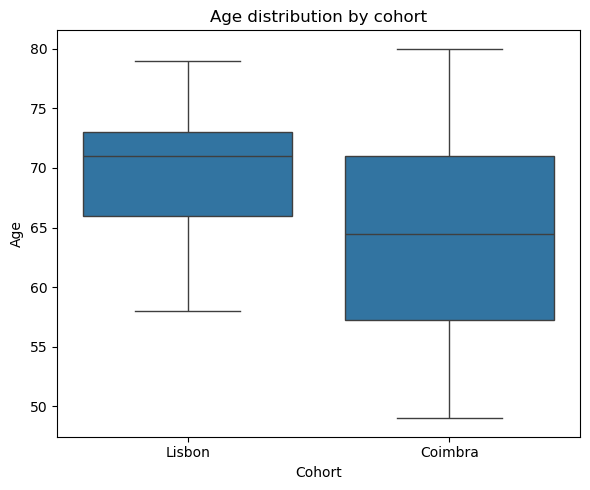

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

output_dir = "grey_study"
os.makedirs(output_dir, exist_ok=True)
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="age"
)

plt.title("Age distribution by cohort")
plt.ylabel("Age")
plt.xlabel("Cohort")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Age_distribution_by_cohort.png"),
    dpi=300
)

plt.show()

In [17]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["sex"]
)

sex,F,M
cohort,,
Coimbra,13,9
Lisbon,26,19


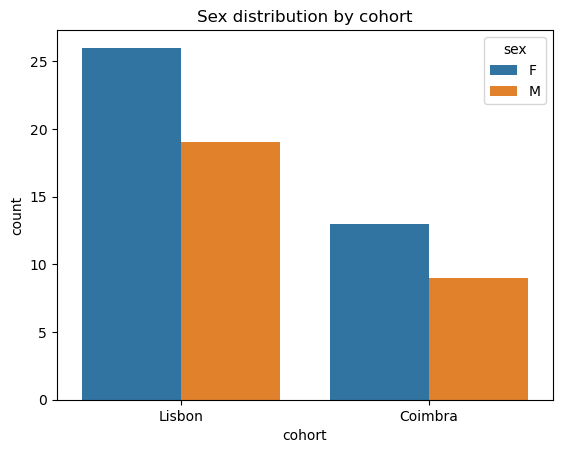

In [18]:
sns.countplot(
    data=char_pop_filtered,
    x="cohort",
    hue="sex"
)

plt.title("Sex distribution by cohort")
plt.show()

In [19]:
char_pop_filtered["MMSE"] = (
    char_pop_filtered["MMSE"]
    .replace("ND", np.nan)
)
char_pop_filtered["MMSE"] = pd.to_numeric(
    char_pop_filtered["MMSE"]
)

In [20]:
char_pop_filtered.groupby("cohort")["MMSE"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,19.0,25.473684,1.954153,21.0,25.0,25.0,27.0,29.0
Lisbon,38.0,25.447368,2.367544,21.0,24.0,25.0,27.0,30.0


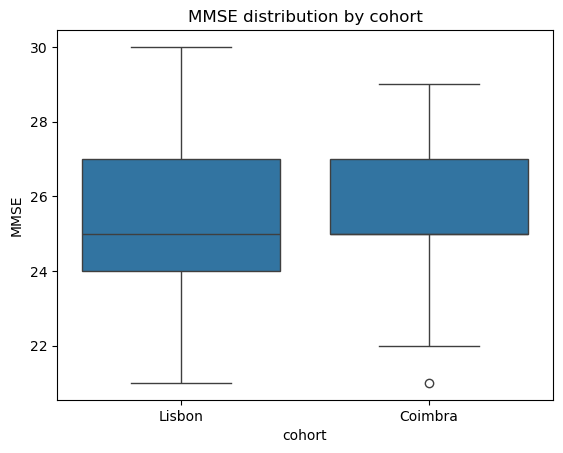

In [21]:
sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="MMSE"
)

plt.title("MMSE distribution by cohort")
plt.show()

In [22]:
char_pop_filtered.groupby("cohort")["schooling"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lisbon,37.0,12.162162,3.847896,2.0,10.0,11.0,16.0,17.0


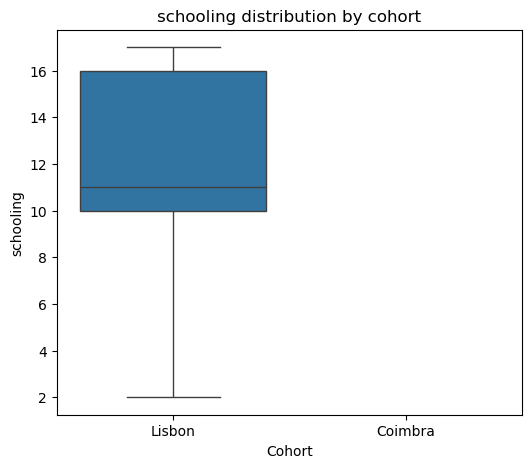

In [23]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="schooling"
)

plt.title("schooling distribution by cohort")
plt.ylabel("schooling")
plt.xlabel("Cohort")

plt.show()

In [24]:
char_pop_filtered.groupby("cohort")["abeta42"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,22.0,461.950313,87.337499,303.03,402.6575,452.85,527.359081,611.044491
Lisbon,45.0,494.333333,107.466062,273.00,421.0000,494.00,560.000000,855.000000


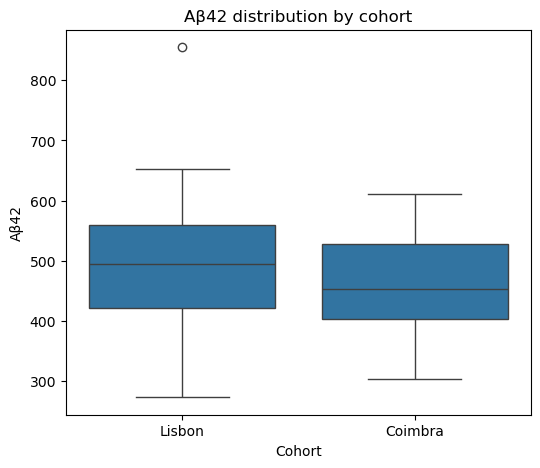

In [25]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="abeta42"
)

plt.title("Aβ42 distribution by cohort")
plt.ylabel("Aβ42")
plt.xlabel("Cohort")

plt.show()

In [26]:
char_pop_filtered.columns

Index(['patient_id', 'bba_status', 'diagnosis', 'age', 'sex', 'tTau', 'pTau',
       'abeta42', 'schooling', 'MMSE', 'comments', 'cohort',
       'patient_id_clean'],
      dtype='object')

In [27]:
char_pop_filtered.groupby("cohort")["pTau"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,22.0,91.915798,51.439511,18.2,57.6,71.3,118.678105,221.1
Lisbon,45.0,84.177778,36.039302,16.0,60.0,77.0,111.000000,165.0


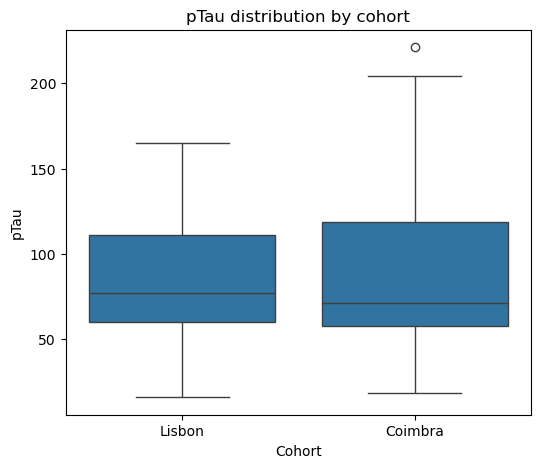

In [28]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=char_pop_filtered,
    x="cohort",
    y="pTau"
)

plt.title("pTau distribution by cohort")
plt.ylabel("pTau")
plt.xlabel("Cohort")

plt.show()

In [29]:
char_pop_filtered["tTau"] = (
    char_pop_filtered["tTau"]
    .replace(">1200", 1200)
)

char_pop_filtered["tTau"] = pd.to_numeric(
    char_pop_filtered["tTau"]
)

In [30]:
char_pop_filtered.groupby("cohort")["tTau"].describe()

,count,mean,std,min,25%,50%,75%,max
cohort,,,,,,,,
Coimbra,22.0,637.007862,303.657298,105.0,428.3,586.243602,705.375,1347.0
Lisbon,45.0,745.511111,426.138402,119.0,498.0,618.000000,929.000,1850.0


In [31]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["diagnosis"]
)

diagnosis,1.0
cohort,
Coimbra,22
Lisbon,45


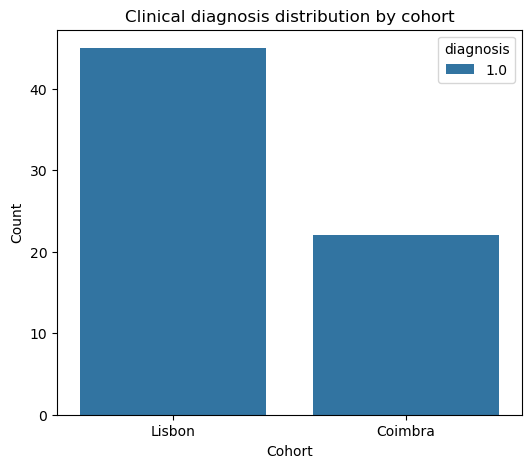

In [32]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=char_pop_filtered,
    x="cohort",
    hue="diagnosis"
)

plt.title("Clinical diagnosis distribution by cohort")
plt.xlabel("Cohort")
plt.ylabel("Count")

plt.show()

In [33]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["bba_status"]
)

bba_status,Abeta-Positivo,BBA+
cohort,,
Coimbra,22,0
Lisbon,0,45


In [34]:
char_pop_filtered["bba_status"] = (
    char_pop_filtered["bba_status"]
    .replace({
        "Abeta-Positivo": "Positive",
        "BBA+": "Positive",

        "Abeta-Negativo": "Negative",
        "BBA normal": "Negative",

        "BBA ?": "Intermediate"
    })
)

In [35]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["bba_status"]
)

bba_status,Positive
cohort,
Coimbra,22
Lisbon,45


In [36]:
char_pop_filtered[
    char_pop_filtered["bba_status"] == "Intermediate"
]

,patient_id,bba_status,diagnosis,age,sex,tTau,pTau,abeta42,schooling,MMSE,comments,cohort,patient_id_clean


In [37]:
pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["diagnosis"]
)

diagnosis,1.0
cohort,
Coimbra,22
Lisbon,45


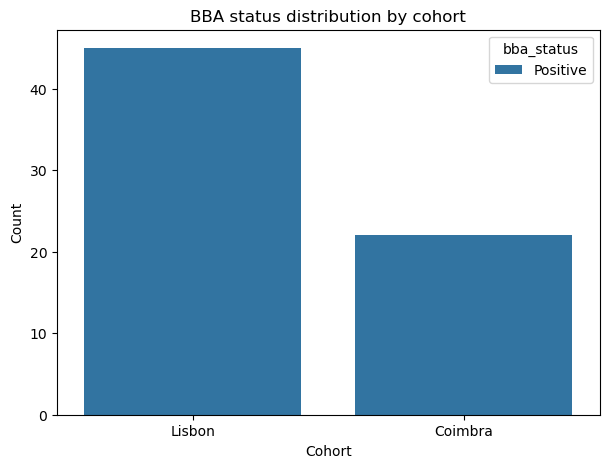

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=char_pop_filtered,
    x="cohort",
    hue="bba_status"
)

plt.title("BBA status distribution by cohort")
plt.xlabel("Cohort")
plt.ylabel("Count")

plt.show()

## Distribution Assessment

Before performing statistical comparisons between cohorts, the distribution of continuous variables was assessed. This step is essential to determine whether parametric or non-parametric statistical tests are more appropriate.

Variables evaluated included:
- age
- years of education
- MMSE
- Aβ42
- tTau
- pTau

Distribution inspection also provides important biological insights into cohort heterogeneity, variability, and the presence of potential outliers or subgroup structures. In particular, biomarker distributions may reveal differences in disease severity and biological heterogeneity between the Lisbon and Coimbra cohorts.

Kernel density estimation (KDE) plots and violin plots were used to visually inspect the distribution shape, skewness, dispersion, and potential multimodality of each variable.

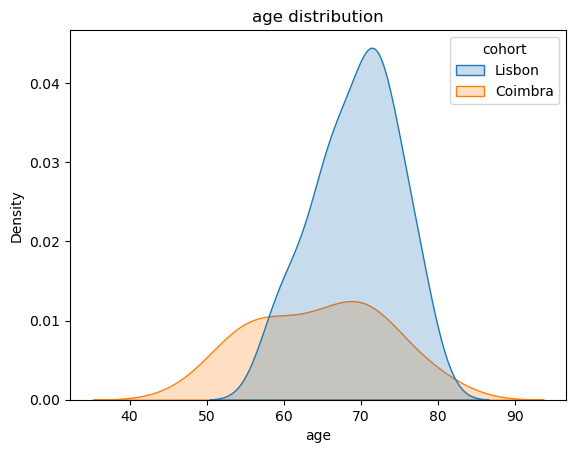

In [39]:
sns.kdeplot(
    data=char_pop_filtered,
    x="age",
    hue="cohort",
    fill=True
)

plt.title("age distribution")
plt.show()

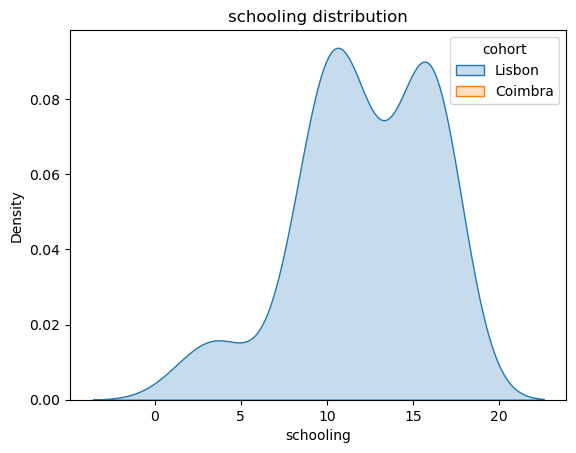

In [40]:
sns.kdeplot(
    data=char_pop_filtered,
    x="schooling",
    hue="cohort",
    fill=True
)

plt.title("schooling distribution")
plt.show()

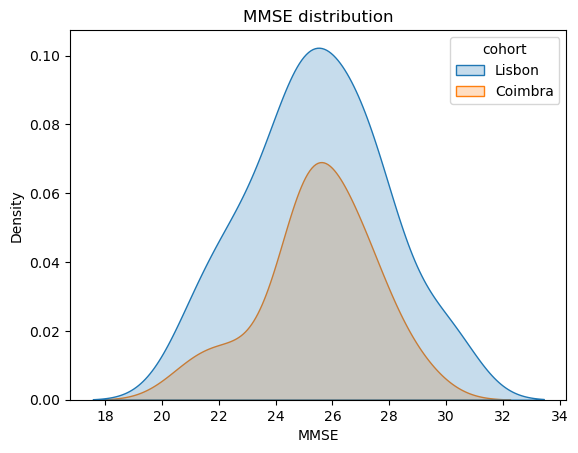

In [41]:
sns.kdeplot(
    data=char_pop_filtered,
    x="MMSE",
    hue="cohort",
    fill=True
)

plt.title("MMSE distribution")
plt.show()


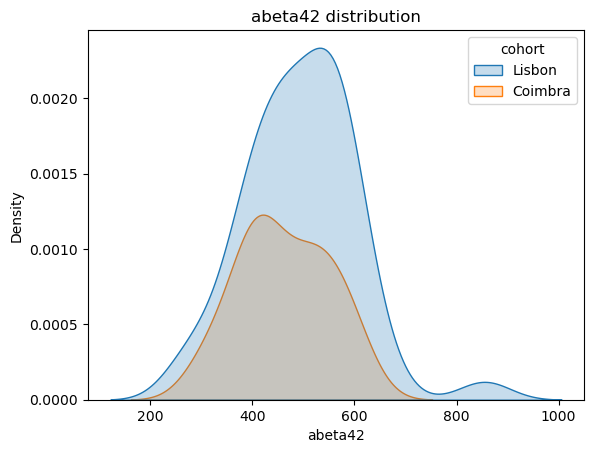

In [42]:
sns.kdeplot(
    data=char_pop_filtered,
    x="abeta42",
    hue="cohort",
    fill=True
)

plt.title("abeta42 distribution")
plt.show()


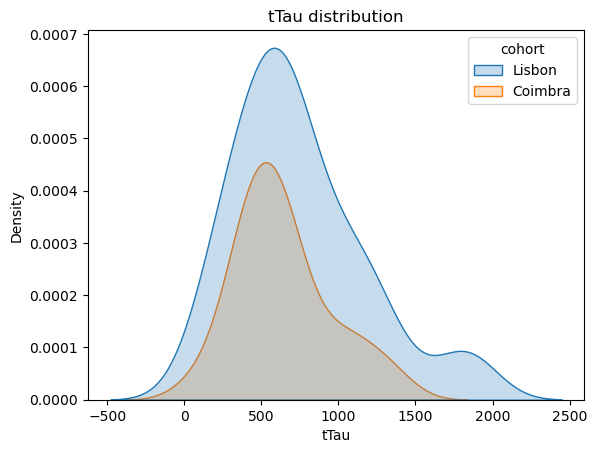

In [43]:
sns.kdeplot(
    data=char_pop_filtered,
    x="tTau",
    hue="cohort",
    fill=True
)

plt.title("tTau distribution")
plt.show()


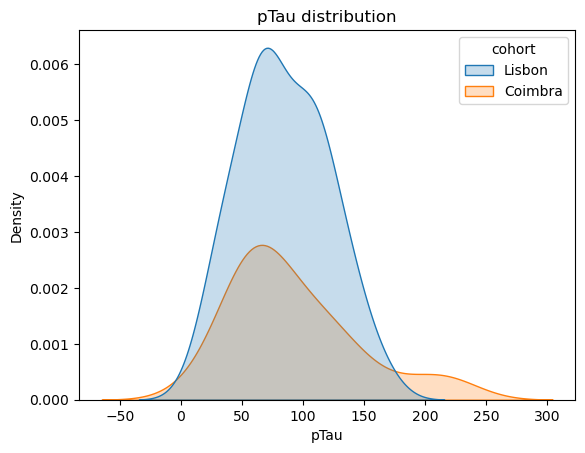

In [44]:
sns.kdeplot(
    data=char_pop_filtered,
    x="pTau",
    hue="cohort",
    fill=True
)

plt.title("pTau distribution")
plt.show()


## Statistical Strategy

Continuous variables were compared between cohorts using the Mann–Whitney U test. Although some variables, such as age, showed approximately unimodal distributions, several clinical and biomarker variables displayed non-Gaussian characteristics, including skewness and dispersion differences between cohorts.

A non-parametric approach was therefore selected to provide a robust and consistent statistical framework across all continuous variables, including:
- age
- years of education
- MMSE
- Aβ42
- tTau
- pTau

Categorical variables, including sex, diagnosis, and biomarker status classification, were evaluated using chi-square tests (or Fisher’s exact test when appropriate).

In [45]:
from scipy.stats import mannwhitneyu

variables = [
    "age",
    "MMSE",
    "abeta42",
    "tTau",
    "pTau"
]

for var in variables:

    lisbon = char_pop_filtered[
        char_pop_filtered["cohort"] == "Lisbon"
    ][var].dropna()

    coimbra = char_pop_filtered[
        char_pop_filtered["cohort"] == "Coimbra"
    ][var].dropna()

    stat, p = mannwhitneyu(
        lisbon,
        coimbra,
        alternative="two-sided"
    )

    print(f"{var}")
    print(f"U statistic = {stat:.3f}")
    print(f"p-value = {p:.5f}")
    print("-" * 30)

age
U statistic = 669.000
p-value = 0.02030
------------------------------
MMSE
U statistic = 351.500
p-value = 0.87718
------------------------------
abeta42
U statistic = 583.000
p-value = 0.24270
------------------------------
tTau
U statistic = 562.500
p-value = 0.37103
------------------------------
pTau
U statistic = 495.000
p-value = 1.00000
------------------------------


In [46]:
sex_table = pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["sex"]
)

print(sex_table)

sex       F   M
cohort         
Coimbra  13   9
Lisbon   26  19


In [47]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(sex_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.5f}")


Chi-square statistic: 0.000
p-value: 1.00000


In [48]:
diag_table = pd.crosstab(
    char_pop_filtered["cohort"],
    char_pop_filtered["diagnosis"]
)

print(diag_table)

diagnosis  1.0
cohort        
Coimbra     22
Lisbon      45


In [49]:
chi2, p, dof, expected = chi2_contingency(diag_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.5f}")

Chi-square statistic: 0.000
p-value: 1.00000


## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was performed on the proteomic profiles of amyloid-positive subjects to investigate the global organization of the proteomic space and assess whether the major sources of variance were associated with cohort identity or clinical/biological variables.

PCA was initially used to visualize the distribution of Lisbon and Coimbra subjects in the reduced proteomic space. Despite comparable clinical and CSF biomarker profiles between cohorts, the first two principal components revealed a strong cohort-dependent organization of the samples.

To biologically interpret the PCA axes, correlation analyses were subsequently performed between principal components (PC1 and PC2) and relevant clinical/biomarker variables, including:
- age
- MMSE
- Aβ42
- tTau
- pTau
- follow-up time

Spearman correlation analysis was selected due to the non-parametric nature of several clinical variables.

These analyses aimed to determine whether the observed proteomic organization reflected known neurodegenerative markers, disease progression variables, or other cohort-associated biological structures.

The results showed that PC1 was strongly associated with tau-related biomarkers (tTau and pTau), suggesting that this axis captures a shared neurodegenerative component across cohorts. In contrast, the separation between Lisbon and Coimbra samples was primarily observed along PC2, which showed only weak-to-moderate associations with clinical and biomarker variables, indicating the presence of an additional cohort-associated proteomic organization not fully explained by standard clinical measures.

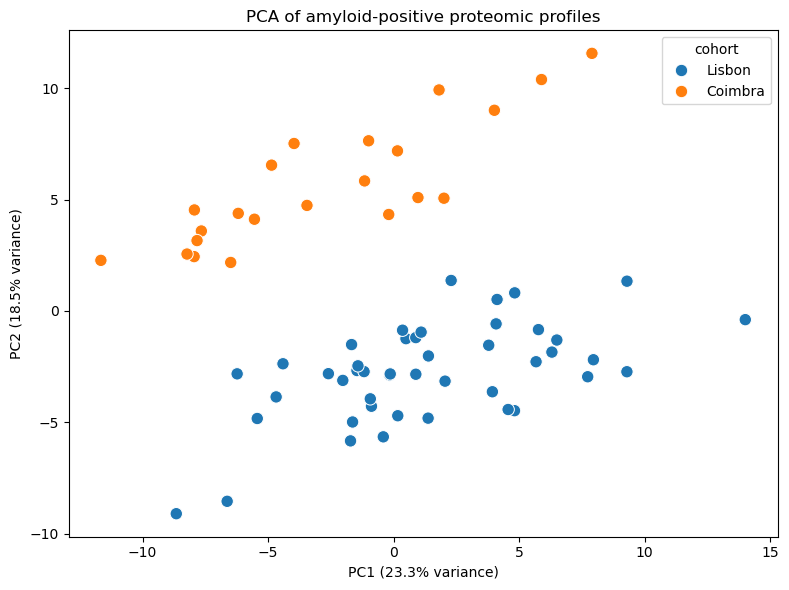

In [50]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Standardize proteomic data
# =========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(LC_df)

# =========================
# PCA
# =========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# =========================
# Create dataframe
# =========================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=LC_df.index
)

# =========================
# Add cohort labels
# =========================

pca_df["cohort"] = [
    "Lisbon" if str(idx).startswith("LIS") else "Coimbra"
    for idx in pca_df.index
]

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cohort",
    s=80
)

plt.title("PCA of amyloid-positive proteomic profiles")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "PCA_amyloid_positive_proteomic_profiles.png"
    ),
    dpi=300
)

plt.show()

In [51]:
fu = pd.read_excel('Copia di BBA amyloid+ follow-up Lisboa e Coimbra final.xlsx')

In [52]:
fu

,Code,BBA,idade,sexo,CSF date,CSF data tTau,CSF data pTau,CSF data abeta42,MMSE,comentários,conversão em demência conversão=1,data,tempo follow-up
0,LIS-008,BBA+,63,F,2014-09-02,200,26.00,324.000000,22,NaN,1,2017-10-15 00:00:00,3.120548
1,LIS-011,BBA+,59,F,2015-02-06,540,74.00,504.000000,24,NaN,1,2018-02-15 00:00:00,3.027397
2,LIS-001,BBA+,76,F,2015-01-26,618,95.00,552.000000,27,NaN,1,2021-10-15 00:00:00,6.723288
3,LIS-031,BBA+,67,F,2015-10-09,892,117.00,512.000000,21,NaN,1,2021-11-15 00:00:00,6.106849
4,LIS-029,BBA+,71,M,2015-09-30,702,86.00,558.000000,26,NaN,1,2019-07-15 00:00:00,3.791781
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,107702,Abeta-Positivo,54,F,2018-06-19,564.487205,84.01,415.916096,26,NaN,1,2020,2.000000
67,108726,Abeta-Positivo,55,F,2019-05-20,1206,221.10,480.000000,28,sem follow-up,ND,NaN,NaN
68,109089,Abeta-Positivo,64,M,2019-08-22,1347,204.20,451.000000,25,NaN,1,2021,2.000000
69,109522,Abeta-Positivo,64,M,2019-12-05,105,18.20,417.000000,29,sem follow-up,ND,NaN,NaN


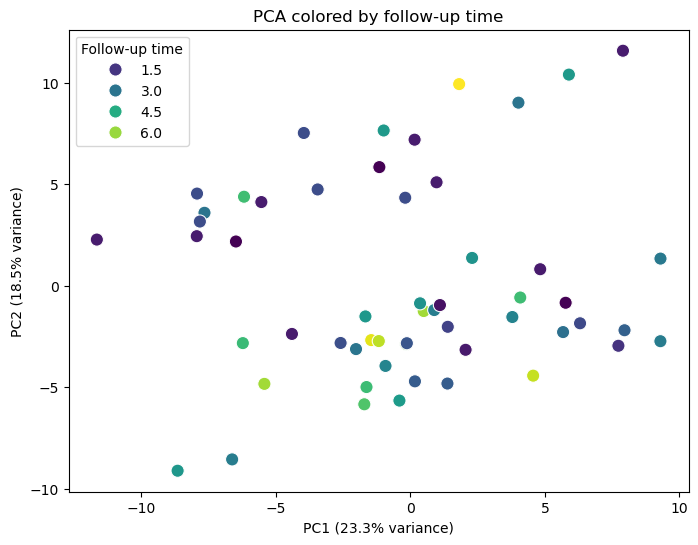

In [53]:
# =========================
# Add follow-up time to PCA dataframe
# =========================

followup_map = dict(
    zip(
        fu["Code"].astype(str).str.replace("-", "", regex=False),
        fu["tempo follow-up"]
    )
)

pca_df["followup_time"] = (
    pca_df.index
    .map(followup_map)
)

# =========================
# Plot PCA colored by follow-up
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="followup_time",
    palette="viridis",
    s=90
)

plt.title("PCA colored by follow-up time")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.legend(title="Follow-up time")

plt.show()

In [54]:
from scipy.stats import spearmanr

rho_pc1, p_pc1 = spearmanr(
    pca_df["PC1"],
    pca_df["followup_time"],
    nan_policy="omit"
)

rho_pc2, p_pc2 = spearmanr(
    pca_df["PC2"],
    pca_df["followup_time"],
    nan_policy="omit"
)

print("PC1 correlation")
print(rho_pc1, p_pc1)

print("PC2 correlation")
print(rho_pc2, p_pc2)

PC1 correlation
-0.018236982302432703 0.894862885605591
PC2 correlation
-0.31819020013214755 0.017911019957234105


In [55]:
from scipy.stats import spearmanr
import pandas as pd

# =========================
# Variables to test
# =========================

variables = [
    "age",
    "MMSE",
    "abeta42",
    "tTau",
    "pTau",
]

# =========================
# Merge clinical variables into PCA dataframe
# =========================

clinical_vars = char_pop_filtered.set_index(
    "patient_id_clean"
)[variables]

pca_corr_df = pca_df.join(
    clinical_vars,
    how="left"
)

# =========================
# Correlation analysis
# =========================

results = []

for var in variables:

    rho_pc1, p_pc1 = spearmanr(
        pca_corr_df["PC1"],
        pca_corr_df[var],
        nan_policy="omit"
    )

    rho_pc2, p_pc2 = spearmanr(
        pca_corr_df["PC2"],
        pca_corr_df[var],
        nan_policy="omit"
    )

    results.append({
        "Variable": var,
        "PC1 rho": rho_pc1,
        "PC1 p-value": p_pc1,
        "PC2 rho": rho_pc2,
        "PC2 p-value": p_pc2
    })

# =========================
# Results table
# =========================

corr_results = pd.DataFrame(results)

print(corr_results)

  Variable   PC1 rho  PC1 p-value   PC2 rho  PC2 p-value
0      age  0.003279     0.978993 -0.260431     0.033297
1     MMSE  0.089154     0.509576 -0.009533     0.943889
2  abeta42 -0.111566     0.368744 -0.288642     0.017844
3     tTau -0.478699     0.000042 -0.262237     0.032051
4     pTau -0.550590     0.000001 -0.198869     0.106672


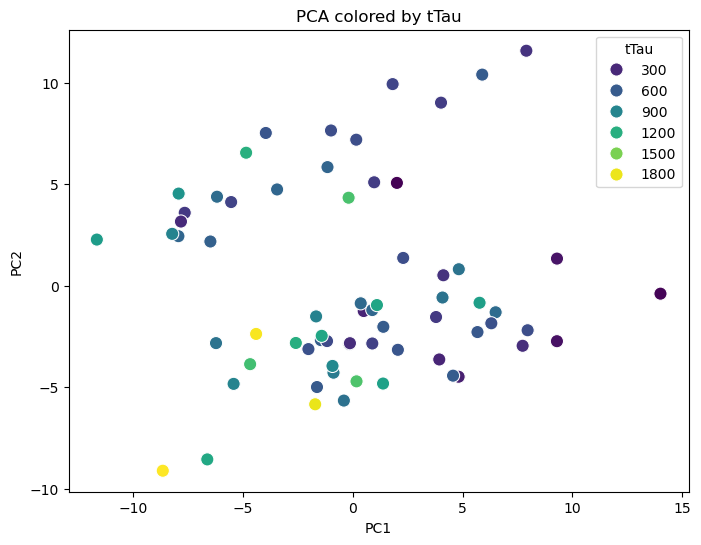

In [56]:
# add tTau to PCA dataframe

ttau_map = dict(
    zip(
        char_pop_filtered["patient_id_clean"],
        char_pop_filtered["tTau"]
    )
)

pca_df["tTau"] = pca_df.index.map(ttau_map)

# plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="tTau",
    palette="viridis",
    s=90
)

plt.title("PCA colored by tTau")
plt.show()

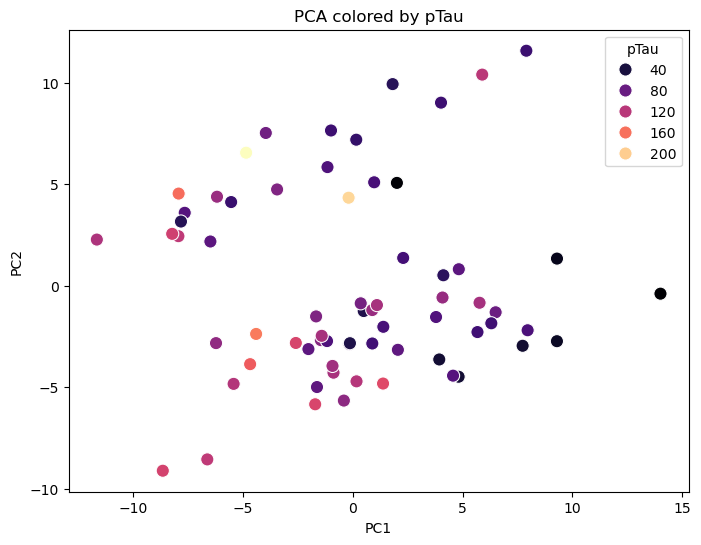

In [57]:
ptau_map = dict(
    zip(
        char_pop_filtered["patient_id_clean"],
        char_pop_filtered["pTau"]
    )
)

pca_df["pTau"] = pca_df.index.map(ptau_map)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="pTau",
    palette="magma",
    s=90
)

plt.title("PCA colored by pTau")
plt.show()

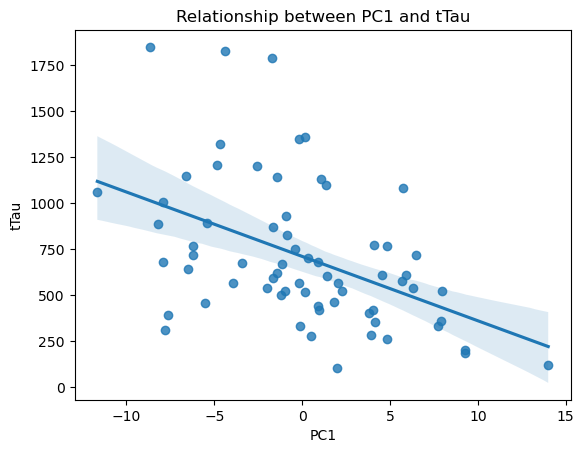

In [58]:
sns.regplot(
    data=pca_df,
    x="PC1",
    y="tTau"
)

plt.title("Relationship between PC1 and tTau")
plt.show()

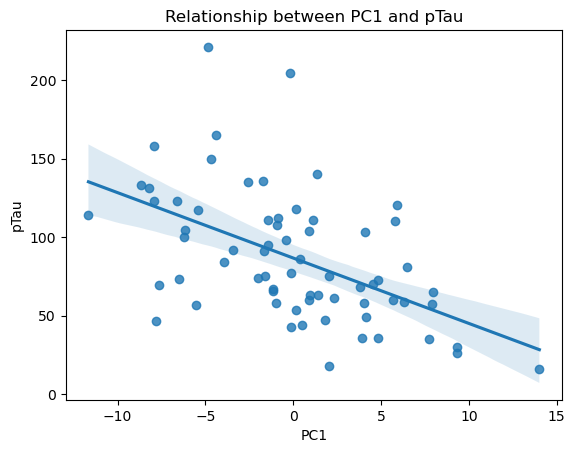

In [59]:
sns.regplot(
    data=pca_df,
    x="PC1",
    y="pTau"
)

plt.title("Relationship between PC1 and pTau")
plt.show()

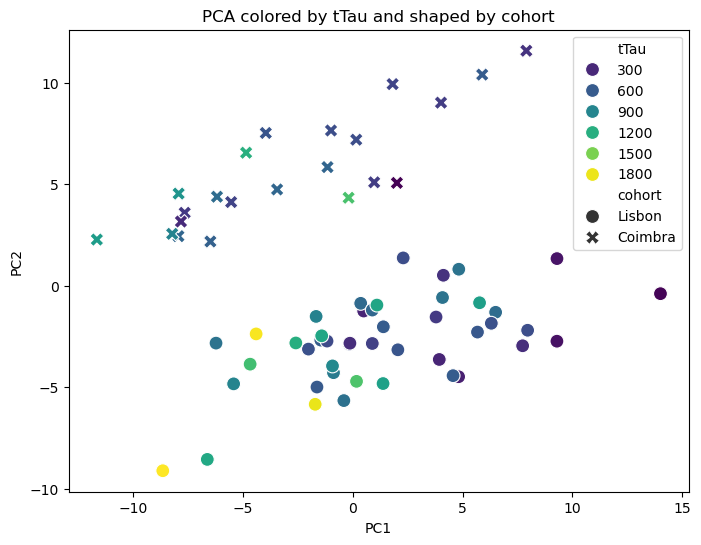

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="tTau",
    style="cohort",
    palette="viridis",
    s=100
)

plt.title("PCA colored by tTau and shaped by cohort")
plt.show()

## Potential Sources of Cohort-Associated Proteomic Separation

Although Lisbon and Coimbra amyloid-positive subjects showed highly comparable clinical and CSF biomarker profiles, PCA revealed a strong cohort-associated organization of the proteomic space. Correlation analyses demonstrated that the principal source of biological variability captured by PC1 was associated with tau-related neurodegeneration, while the cohort separation itself was primarily observed along PC2 and was only weakly explained by available clinical variables.

Several non-mutually exclusive hypotheses may explain this cohort-associated structure:

### 1. Subtype composition differences
The two cohorts may contain different proportions of underlying molecular AD subtypes. Even if the same biological programs are conserved across cohorts, distinct subtype prevalence or subtype intensity could globally reorganize the proteomic space.

### 2. Disease progression heterogeneity
Differences in progression trajectories, disease staging, or conversion dynamics may contribute to the observed organization. Standard biomarkers such as MMSE, Aβ42, tTau, and pTau may not fully capture these more subtle molecular progression states.

### 3. Cohort-specific biological organization
Independent cohorts may present distinct inflammatory, synaptic, metabolic, or vascular proteomic signatures despite similar core AD biomarker profiles. Such differences could reflect environmental, demographic, recruitment-related, or genetic factors.

### 4. Residual technical or center-specific effects
Although harmonization and batch-correction procedures were previously applied, subtle residual center-associated effects cannot be completely excluded. These effects may arise from sample handling, storage duration, acquisition timing, or other technical variables not fully captured by standard preprocessing pipelines.

### 5. Hidden proteomic structure not captured by standard clinical variables
Proteomic data may encode latent biological information not reflected by conventional CSF biomarkers or cognitive measures. The persistence of cohort-associated separation despite comparable clinical profiles suggests the existence of additional molecular dimensions underlying AD heterogeneity.

To further investigate the origin of this cohort-associated structure, additional analyses may include:
- PCA loading analysis
- pathway enrichment of PC-associated proteins
- differential expression analysis between cohorts
- variance partitioning analyses
- nonlinear dimensionality reduction approaches (e.g., UMAP)
- cross-cohort subtype transferability analyses

To investigate the strong cohort-associated separation observed between Lisbon and Coimbra subjects in PCA space, we performed three complementary analyses.

### 1. PCA loading analysis
We first examined the proteins contributing most strongly to PC2, the principal component primarily associated with cohort separation. The top PC2 loadings highlighted proteins related to complement activation, extracellular matrix organization, coagulation, and inflammatory pathways.

### 2. Differential abundance analysis
We then directly compared protein abundance between Lisbon and Coimbra subjects using Welch’s t-test with FDR correction. This analysis identified multiple significantly differentially abundant proteins between cohorts, several of which overlapped with the proteins driving PC2.

### 3. Pathway enrichment analysis
Finally, Reactome pathway enrichment analysis was performed separately on proteins enriched in each cohort.

- Proteins elevated in Lisbon were mainly associated with complement activation, innate immune system pathways, coagulation, and platelet-related biology.
- Proteins elevated in Coimbra were primarily enriched for extracellular matrix organization, proteoglycan remodeling, and glycosaminoglycan metabolism pathways.

Overall, the convergence between PCA loadings, differential abundance analysis, and pathway enrichment suggests that the cohort-associated separation is supported by systematic extracellular and immune-related proteomic differences between cohorts.horts.

In [61]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=LC_df.columns,
    columns=["PC1", "PC2"]
)

pc2_loadings = loadings["PC2"].sort_values()

print(pc2_loadings.head(20))
print(pc2_loadings.tail(20))

Protein.Group
P23515   -0.168851
Q99574   -0.152082
P61916   -0.149207
Q12805   -0.145085
P02747   -0.141970
P04216   -0.137822
Q96GW7   -0.133484
P07998   -0.133189
P04180   -0.132775
O75326   -0.126778
P41222   -0.124558
P00736   -0.116993
P01034   -0.099283
Q6MZW2   -0.096528
Q9NT99   -0.087827
Q9Y4C0   -0.086157
P23142   -0.083854
P02746   -0.081230
P02749   -0.066521
P01861   -0.061435
Name: PC2, dtype: float64
Protein.Group
Q12860    0.119018
O00533    0.127483
Q92859    0.128939
P08294    0.132639
P02750    0.132767
P07585    0.134632
P33908    0.137678
Q14118    0.139555
P02751    0.141301
P13611    0.144146
P20774    0.146132
P02452    0.147103
P00450    0.158408
P55058    0.161427
P36955    0.163749
P01023    0.165612
P05060    0.165927
Q9UBP4    0.174114
P25311    0.176887
Q14515    0.181724
Name: PC2, dtype: float64


In [62]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import mygene

# =========================================================
# SPLIT COHORTS FROM INDEX
# =========================================================

lisbon_df = LC_df[
    LC_df.index.str.startswith("LIS")
]

coimbra_df = LC_df[
    ~LC_df.index.str.startswith("LIS")
]

print("Lisbon samples:", lisbon_df.shape[0])
print("Coimbra samples:", coimbra_df.shape[0])

# =========================================================
# DIFFERENTIAL ABUNDANCE ANALYSIS
# =========================================================

results = []

for protein in LC_df.columns:

    lisbon_vals = lisbon_df[protein]
    coimbra_vals = coimbra_df[protein]

    # Welch t-test
    stat, pval = ttest_ind(
        lisbon_vals,
        coimbra_vals,
        equal_var=False,
        nan_policy="omit"
    )

    # mean difference
    logfc = (
        lisbon_vals.mean()
        - coimbra_vals.mean()
    )

    results.append({
        "protein": protein,
        "logFC": logfc,
        "pvalue": pval
    })

# =========================================================
# RESULTS DATAFRAME
# =========================================================

res_df = pd.DataFrame(results)

# =========================================================
# FDR CORRECTION
# =========================================================

res_df["FDR"] = multipletests(
    res_df["pvalue"],
    method="fdr_bh"
)[1]

# =========================================================
# SCORE
# =========================================================

res_df["score"] = (
    np.sign(res_df["logFC"]) *
    -np.log10(res_df["pvalue"])
)

# =========================================================
# UNIPROT → GENE SYMBOL
# =========================================================

mg = mygene.MyGeneInfo()

mapping = mg.querymany(
    res_df["protein"].tolist(),
    scopes="uniprot",
    fields="symbol",
    species="human"
)

mapping_dict = {
    x["query"]: x.get("symbol")
    for x in mapping
    if "symbol" in x
}

res_df["gene_symbol"] = (
    res_df["protein"]
    .map(mapping_dict)
)

# =========================================================
# SORT RESULTS
# =========================================================

res_df = res_df.sort_values("FDR")

# =========================================================
# SHOW TOP RESULTS
# =========================================================

print(
    res_df[
        [
            "gene_symbol",
            "logFC",
            "pvalue",
            "FDR"
        ]
    ].head(30)
)

# =========================================================
# SIGNIFICANT PROTEINS
# =========================================================

sig_df = res_df[
    res_df["FDR"] < 0.05
]

print(f"\nSignificant proteins: {len(sig_df)}")

Lisbon samples: 45
Coimbra samples: 22


1 input query terms found dup hits:	[('P0C0L4', 2)]
3 input query terms found no hit:	['A0A0A0MS15', 'A0A0B4J1X8', 'P01861']


    gene_symbol     logFC        pvalue           FDR
109        DKK3 -1.797034  1.592867e-19  1.815868e-17
68          OMG  1.757414  1.308251e-17  7.457029e-16
34         CHGB -1.704587  2.207609e-17  8.388915e-16
104    SERPINI1  1.694703  2.424499e-16  6.909823e-15
31         LCAT  1.551933  2.356539e-15  5.372908e-14
20         C1QC  1.765282  8.119971e-14  1.542794e-12
2          CHL1 -1.581466  3.928857e-12  5.598621e-11
88      SPARCL1 -1.534834  3.899566e-12  5.598621e-11
75        PTGDS  1.723971  1.032755e-10  1.308156e-09
83       EFEMP1  1.614610  1.298960e-10  1.480814e-09
81         PLTP -1.393488  3.572486e-10  3.702395e-09
71       MAN1A1 -1.360122  1.010941e-09  9.603943e-09
59         VCAN -1.380681  1.269568e-09  1.033791e-08
101        NEO1 -1.501523  1.191631e-09  1.033791e-08
79     CACNA2D1 -1.357716  4.764364e-08  3.478111e-07
82         NPC2  1.516353  4.881559e-08  3.478111e-07
7           C1R  1.493028  5.280262e-08  3.540881e-07
32         THY1  1.190690  1

Overlap = 31 proteins


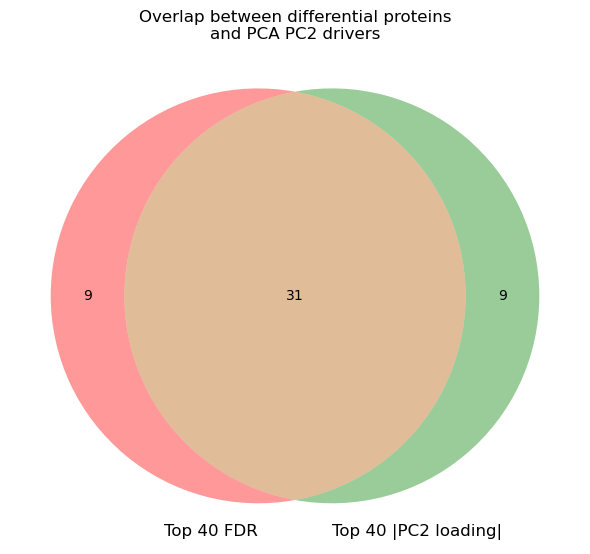

In [63]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Top 40 FDR
top_fdr = set(
    res_df.head(40)["protein"]
)

# Top 40 PC2 loadings (valore assoluto)
top_pc2 = set(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(40)
    .index
)

# Overlap
overlap = top_fdr & top_pc2

print(f"Overlap = {len(overlap)} proteins")

plt.figure(figsize=(6,6))

venn2(
    [top_fdr, top_pc2],
    set_labels=(
        "Top 40 FDR",
        "Top 40 |PC2 loading|"
    )
)

plt.title(
    "Overlap between differential proteins\nand PCA PC2 drivers"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Venn_FDR_vs_PC2_overlap.png"
    ),
    dpi=300
)

plt.show()

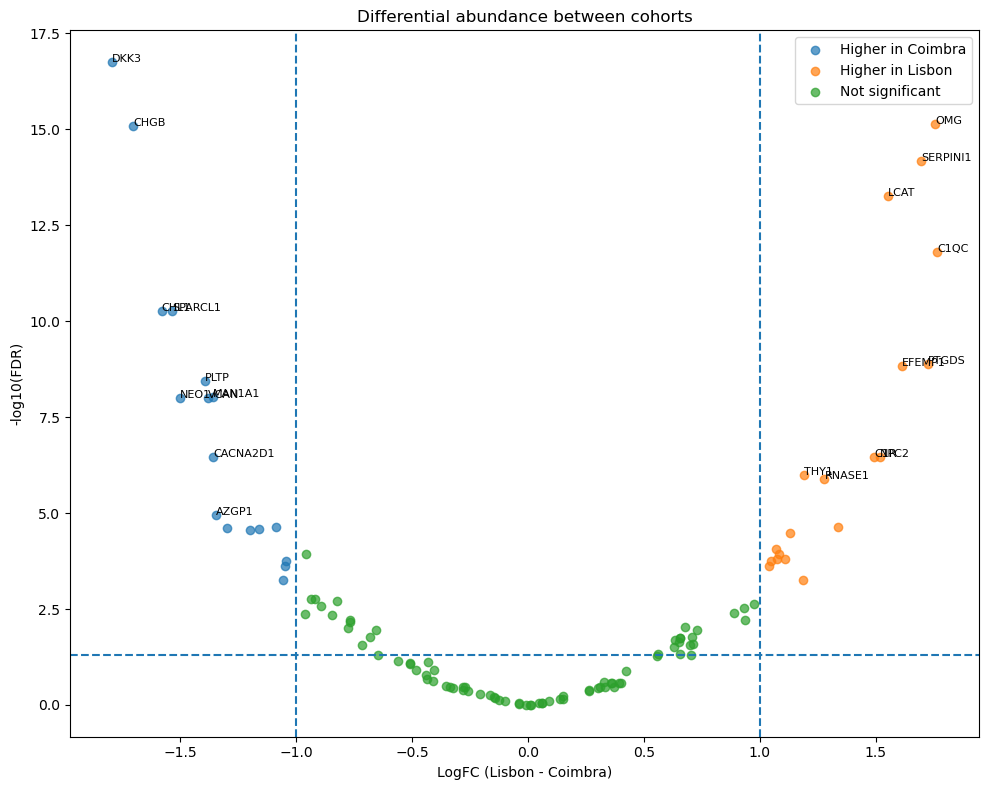

In [64]:
# =========================================================
# VOLCANO PLOT
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# copy dataframe
plot_df = res_df.copy()

# -log10 FDR
plot_df["minus_log10_FDR"] = -np.log10(plot_df["FDR"])

# thresholds
fdr_thresh = 0.05
logfc_thresh = 1

# define groups
plot_df["group"] = "Not significant"

plot_df.loc[
    (plot_df["FDR"] < fdr_thresh) &
    (plot_df["logFC"] > logfc_thresh),
    "group"
] = "Higher in Lisbon"

plot_df.loc[
    (plot_df["FDR"] < fdr_thresh) &
    (plot_df["logFC"] < -logfc_thresh),
    "group"
] = "Higher in Coimbra"

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

for grp in plot_df["group"].unique():

    tmp = plot_df[
        plot_df["group"] == grp
    ]

    ax.scatter(
        tmp["logFC"],
        tmp["minus_log10_FDR"],
        alpha=0.7,
        label=grp
    )

# significance lines
ax.axhline(
    -np.log10(fdr_thresh),
    linestyle="--"
)

ax.axvline(
    logfc_thresh,
    linestyle="--"
)

ax.axvline(
    -logfc_thresh,
    linestyle="--"
)

# ---------------------------------------------------------
# LABEL TOP PROTEINS
# ---------------------------------------------------------

top_labels = (
    plot_df
    .sort_values("FDR")
    .head(20)
)

for _, row in top_labels.iterrows():

    ax.text(
        row["logFC"],
        row["minus_log10_FDR"],
        row["gene_symbol"],
        fontsize=8
    )

# labels
ax.set_xlabel("LogFC (Lisbon - Coimbra)")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Differential abundance between cohorts")

ax.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Volcano_Lisbon_vs_Coimbra.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [66]:
up_lisbon = (
    res_df[
        (res_df["FDR"] < 0.05) &
        (res_df["logFC"] > 0)
    ]["gene_symbol"]
    .dropna()
    .tolist()
)

up_coimbra = (
    res_df[
        (res_df["FDR"] < 0.05) &
        (res_df["logFC"] < 0)
    ]["gene_symbol"]
    .dropna()
    .tolist()
)

In [67]:
# =========================================================
# REACTOME ENRICHMENT
# =========================================================

import gseapy as gp

# ---------------------------------------------------------
# LISBON-UP PROTEINS
# ---------------------------------------------------------

enr_lisbon_reactome = gp.enrichr(
    gene_list=up_lisbon,
    gene_sets=["Reactome_2022"],
    organism="human",
    outdir=None
)

# ---------------------------------------------------------
# COIMBRA-UP PROTEINS
# ---------------------------------------------------------

enr_coimbra_reactome = gp.enrichr(
    gene_list=up_coimbra,
    gene_sets=["Reactome_2022"],
    organism="human",
    outdir=None
)

# ---------------------------------------------------------
# SHOW RESULTS
# ---------------------------------------------------------

print(
    enr_lisbon_reactome.results
    .sort_values("Adjusted P-value")
    .head(20)
)

print(
    enr_coimbra_reactome.results
    .sort_values("Adjusted P-value")
    .head(20)
)

         Gene_set                                               Term  Overlap  \
0   Reactome_2022  Classical Antibody-Mediated Complement Activat...      3/6   
1   Reactome_2022                  Innate Immune System R-HSA-168249  11/1035   
2   Reactome_2022      Regulation Of Complement Cascade R-HSA-977606     4/45   
3   Reactome_2022      Creation Of C4 And C2 Activators R-HSA-166786     3/14   
4   Reactome_2022                    Complement Cascade R-HSA-166658     4/55   
5   Reactome_2022      Initial Triggering Of Complement R-HSA-166663     3/21   
6   Reactome_2022    Extracellular Matrix Organization R-HSA-1474244    6/291   
7   Reactome_2022               Amyloid Fiber Formation R-HSA-977225     4/79   
8   Reactome_2022             Neutrophil Degranulation R-HSA-6798695    7/468   
9   Reactome_2022                         Immune System R-HSA-168256  12/1943   
10  Reactome_2022                            Hemostasis R-HSA-109582    7/576   
13  Reactome_2022           

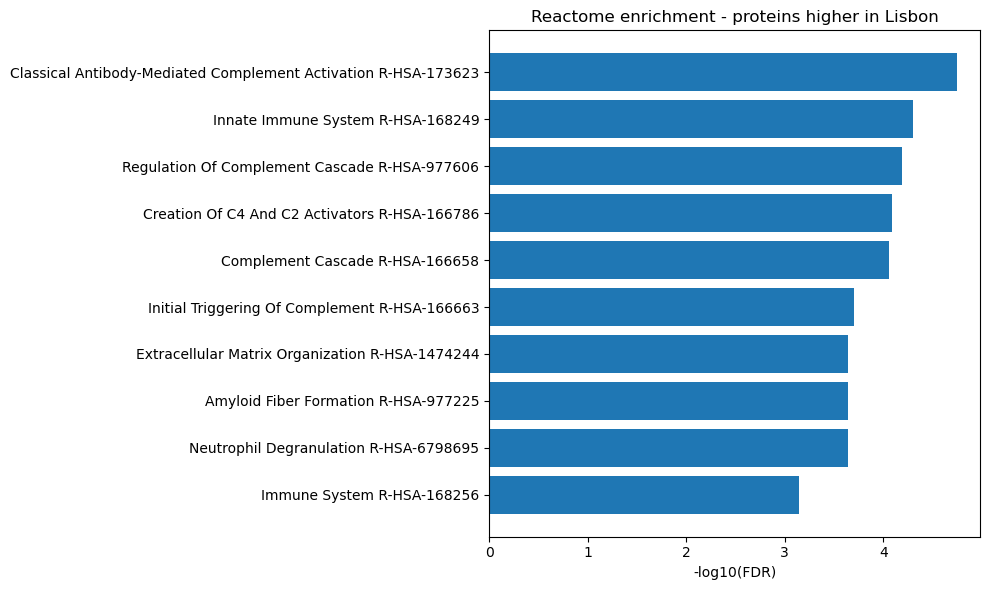

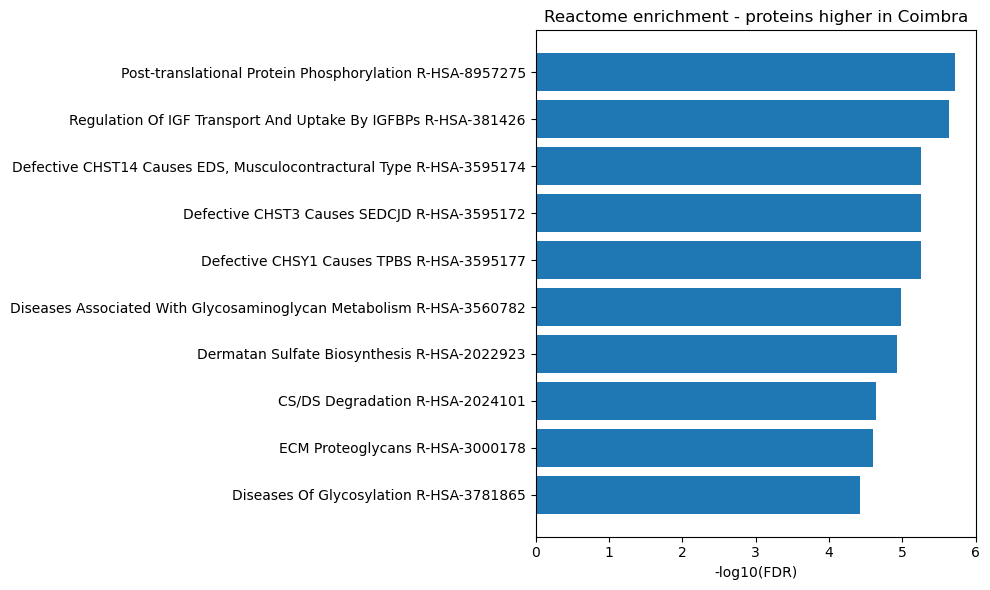

In [74]:
# =========================================================
# VISUALIZE REACTOME ENRICHMENT
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# LISBON
# ---------------------------------------------------------

lisbon_plot = (
    enr_lisbon_reactome.results
    .sort_values("Adjusted P-value")
    .head(10)
    .copy()
)

lisbon_plot["minus_log10_FDR"] = (
    -np.log10(lisbon_plot["Adjusted P-value"])
)

lisbon_plot = lisbon_plot.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    lisbon_plot["Term"],
    lisbon_plot["minus_log10_FDR"]
)

ax.set_xlabel("-log10(FDR)")
ax.set_title("Reactome enrichment - proteins higher in Lisbon")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Reactome_enrichment_higher_in_Lisbon.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

# ---------------------------------------------------------
# COIMBRA
# ---------------------------------------------------------

coimbra_plot = (
    enr_coimbra_reactome.results
    .sort_values("Adjusted P-value")
    .head(10)
    .copy()
)

coimbra_plot["minus_log10_FDR"] = (
    -np.log10(coimbra_plot["Adjusted P-value"])
)

coimbra_plot = coimbra_plot.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    coimbra_plot["Term"],
    coimbra_plot["minus_log10_FDR"]
)

ax.set_xlabel("-log10(FDR)")
ax.set_title("Reactome enrichment - proteins higher in Coimbra")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Reactome_enrichment_higher_in_Coimbra.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [69]:
enr_lisbon_reactome.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_2022,Classical Antibody-Mediated Complement Activat...,3/6,8.156593e-08,0.000018,0,0,665.466667,10861.649901,C1QB;C1R;C1QC
1,Reactome_2022,Innate Immune System R-HSA-168249,11/1035,4.568521e-07,0.000051,0,0,9.249512,135.032754,C1QB;CST3;TTR;GSN;PKM;C1R;NPC2;PROS1;RNASE1;CD...
2,Reactome_2022,Regulation Of Complement Cascade R-HSA-977606,4/45,8.722076e-07,0.000065,0,0,67.034483,935.281085,C1QB;C1R;PROS1;C1QC
3,Reactome_2022,Creation Of C4 And C2 Activators R-HSA-166786,3/14,1.471253e-06,0.000082,0,0,181.418182,2436.336634,C1QB;C1R;C1QC
4,Reactome_2022,Complement Cascade R-HSA-166658,4/55,1.973499e-06,0.000088,0,0,53.863421,707.533863,C1QB;C1R;PROS1;C1QC
...,...,...,...,...,...,...,...,...,...,...
217,Reactome_2022,Cellular Responses To Stress R-HSA-2262752,1/722,7.030886e-01,0.715989,0,0,0.834171,0.293855,APOA1
218,Reactome_2022,Adaptive Immune System R-HSA-1280218,1/733,7.086332e-01,0.716584,0,0,0.821166,0.282824,RNASE1
219,Reactome_2022,Cellular Responses To Stimuli R-HSA-8953897,1/736,7.101278e-01,0.716584,0,0,0.817687,0.279903,APOA1
220,Reactome_2022,Signal Transduction R-HSA-162582,3/2465,7.908203e-01,0.794399,0,0,0.711007,0.166862,MMP2;OMG;RNASE1


In [70]:
enr_coimbra_reactome.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_2022,Post-translational Protein Phosphorylation R-H...,6/106,1.269954e-08,0.000002,0,0,47.685600,867.005272,VCAN;FN1;SPARCL1;IGFBP7;CP;CHGB
1,Reactome_2022,Regulation Of IGF Transport And Uptake By IGFB...,6/123,3.106224e-08,0.000002,0,0,40.722051,703.973214,VCAN;FN1;SPARCL1;IGFBP7;CP;CHGB
2,Reactome_2022,"Defective CHST14 Causes EDS, Musculocontractur...",3/8,1.878075e-07,0.000006,0,0,427.800000,6625.701536,VCAN;NCAN;DCN
3,Reactome_2022,Defective CHST3 Causes SEDCJD R-HSA-3595172,3/8,1.878075e-07,0.000006,0,0,427.800000,6625.701536,VCAN;NCAN;DCN
4,Reactome_2022,Defective CHSY1 Causes TPBS R-HSA-3595177,3/8,1.878075e-07,0.000006,0,0,427.800000,6625.701536,VCAN;NCAN;DCN
...,...,...,...,...,...,...,...,...,...,...
143,Reactome_2022,Innate Immune System R-HSA-168249,1/1035,8.076646e-01,0.830100,0,0,0.610413,0.130389,LRG1
144,Reactome_2022,Immune System R-HSA-168256,2/1943,8.177717e-01,0.834691,0,0,0.640551,0.128861,LRG1;FN1
145,Reactome_2022,Generic Transcription Pathway R-HSA-212436,1/1190,8.508968e-01,0.862553,0,0,0.526493,0.085010,COL1A1
146,Reactome_2022,RNA Polymerase II Transcription R-HSA-73857,1/1312,8.781536e-01,0.884127,0,0,0.474396,0.061640,COL1A1


In [71]:
char_pop

,patient_id,bba_status,diagnosis,age,sex,tTau,pTau,abeta42,schooling,MMSE,comments,cohort,patient_id_clean
0,LIS-008,BBA+,1.0,63,F,200,26.0,324.0,4.0,22,NaN,Lisbon,LIS008
1,LIS-011,BBA+,1.0,59,F,540,74.0,504.0,16.0,24,NaN,Lisbon,LIS011
2,LIS-001,BBA+,1.0,76,F,618,95.0,552.0,16.0,27,NaN,Lisbon,LIS001
3,LIS-017,BBA normal,0.0,44,F,197,31.0,767.0,16.0,30,NaN,Lisbon,LIS017
4,LIS-031,BBA+,1.0,67,F,892,117.0,512.0,11.0,21,NaN,Lisbon,LIS031
...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,109901,Abeta-Positivo,1.0,62,M,608,120.2,401.0,NaN,ND,NaN,Coimbra,109901
132,110073,Abeta-Negativo,0.0,46,M,190,29.8,1157.0,NaN,ND,NaN,Coimbra,110073
133,110203,Abeta-Negativo,0.0,54,F,238,30.4,1335.0,NaN,ND,NaN,Coimbra,110203
134,110404,Abeta-Negativo,0.0,43,F,83,15.7,719.0,NaN,29,NaN,Coimbra,110404


In [72]:
# =========================================================
# CONVERTI A NUMERICO
# =========================================================
for var in ['age', 'tTau', 'pTau', 'abeta42']:
    char_pop[var] = pd.to_numeric(char_pop[var], errors='coerce')

# =========================================================
# CONFRONTO CLINICO TRA COORTI
# =========================================================
for var in ['age', 'tTau', 'pTau', 'abeta42']:
    lis = char_pop[char_pop['cohort']=='Lisbon'][var].dropna()
    coi = char_pop[char_pop['cohort']=='Coimbra'][var].dropna()
    
    # salta se troppi NaN
    if len(lis) < 3 or len(coi) < 3:
        print(f"{var}: dati insufficienti")
        continue
        
    stat, pval = ttest_ind(lis, coi, equal_var=False)
    print(f"{var}: Lisbon {lis.mean():.1f}±{lis.std():.1f} | "
          f"Coimbra {coi.mean():.1f}±{coi.std():.1f} | p={pval:.4f}")

# Variabili categoriche
for var in ['sex', 'bba_status', 'diagnosis']:
    ct = pd.crosstab(char_pop['cohort'], char_pop[var])
    chi2, pval, _, _ = chi2_contingency(ct)
    print(f"\n{var} (chi2 p={pval:.4f}):")
    print(ct)

age: Lisbon 67.2±8.1 | Coimbra 62.6±9.1 | p=0.0029
tTau: Lisbon 553.0±399.2 | Coimbra 355.8±287.6 | p=0.0011
pTau: Lisbon 67.5±35.8 | Coimbra 53.8±42.9 | p=0.0498
abeta42: Lisbon 635.6±240.0 | Coimbra 815.5±352.5 | p=0.0010

sex (chi2 p=0.1400):
sex       F   M
cohort         
Coimbra  40  20
Lisbon   40  36

bba_status (chi2 p=0.0000):
bba_status  Abeta-Negativo  Abeta-Positivo  BBA ?  BBA normal  BBA+
cohort                                                             
Coimbra                 37              23      0           0     0
Lisbon                   0               0      5          24    47

diagnosis (chi2 p=0.0026):
diagnosis  0.0  1.0
cohort             
Coimbra     37   23
Lisbon      24   47


In [73]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# =========================================================
# UNISCI PROTEOMICO + CLINICO
# =========================================================
# assumo che LC_df abbia index = patient_id
merged = LC_df.join(
    char_pop.set_index('patient_id_clean')[
        ['age', 'sex', 'tTau', 'pTau', 'abeta42', 'diagnosis', 'cohort']
    ]
)

# converti
merged['cohort_bin'] = (merged['cohort'] == 'Lisbon').astype(int)
merged['sex_bin'] = (merged['sex'] == 'F').astype(int)
for var in ['age', 'tTau', 'pTau', 'abeta42']:
    merged[var] = pd.to_numeric(merged[var], errors='coerce')

# =========================================================
# PRENDI TOP 20 PROTEINE PIU DIFFERENZIALI
# =========================================================
top_proteins = res_df.head(20)['protein'].tolist()

# =========================================================
# REGRESSIONE PER OGNI PROTEINA
# =========================================================
regression_results = []

for prot in top_proteins:
    gene = res_df[res_df['protein'] == prot]['gene_symbol'].values[0]
    
    df_reg = merged[[prot, 'cohort_bin', 'age', 'sex_bin', 
                      'tTau', 'pTau', 'abeta42']].dropna()
    
    if len(df_reg) < 20:
        continue
    
    # modello con solo centro
    m1 = smf.ols(f'{prot} ~ cohort_bin', data=df_reg).fit()
    
    # modello con centro + clinico
    m2 = smf.ols(f'{prot} ~ cohort_bin + age + sex_bin + tTau + pTau + abeta42', 
                 data=df_reg).fit()
    
    regression_results.append({
        'protein': prot,
        'gene': gene,
        'coef_centro_m1': m1.params['cohort_bin'],
        'pval_centro_m1': m1.pvalues['cohort_bin'],
        'coef_centro_m2': m2.params['cohort_bin'],
        'pval_centro_m2': m2.pvalues['cohort_bin'],
        'r2_m1': m1.rsquared,
        'r2_m2': m2.rsquared,
        'delta_r2': m2.rsquared - m1.rsquared
    })

reg_df = pd.DataFrame(regression_results)
print(reg_df[['gene', 'coef_centro_m1', 'pval_centro_m1', 
              'coef_centro_m2', 'pval_centro_m2', 
              'r2_m1', 'r2_m2', 'delta_r2']].to_string())

        gene  coef_centro_m1  pval_centro_m1  coef_centro_m2  pval_centro_m2     r2_m1     r2_m2  delta_r2
0       DKK3       -1.813315    2.382460e-19       -1.704398    8.552920e-16  0.719960  0.763995  0.044036
1        OMG        1.747676    1.929290e-17        1.635137    1.495709e-14  0.679021  0.744434  0.065413
2       CHGB       -1.721476    3.429808e-16       -1.643464    6.017486e-13  0.649053  0.688510  0.039457
3   SERPINI1        1.678906    1.580820e-15        1.812345    2.031590e-15  0.632034  0.714499  0.082465
4       LCAT        1.535509    4.872196e-12        1.611263    1.603244e-10  0.528287  0.568557  0.040270
5       C1QC        1.752666    9.675569e-18        1.664579    1.099429e-13  0.685823  0.703835  0.018013
6       CHL1       -1.586698    9.281594e-13       -1.600416    4.186693e-13  0.551817  0.710421  0.158603
7    SPARCL1       -1.526640    1.119425e-11       -1.267680    3.892272e-08  0.516031  0.604888  0.088857
8      PTGDS        1.715362    2.391

In [77]:
cluster1_lisbon = ['LIS008', 'LIS012', 'LIS018', 'LIS024', 'LIS013', 'LIS040', 'LIS057', 'LIS068', 'LIS027', 'LIS061', 'LIS069', 'LIS103']
cluster2_lisbon = ['LIS011', 'LIS001', 'LIS031', 'LIS035', 'LIS033', 'LIS047', 'LIS004', 'LIS058', 'LIS062', 'LIS085', 'LIS088']
cluster1_lc = ['LIS008', 'LIS024', 'LIS013', 'LIS040', 'LIS057', 'LIS064', 'LIS068', 'LIS027', 'LIS052', 'LIS061', 'LIS069', 'LIS103', 'LIS104', 'LIS116']
cluster2_lc = ['LIS031', 'LIS035', 'LIS033', 'LIS062', '103698', '107702', '108726', '105728', '100855', '106746', '103423', '100112', '104804', '100111', '107362']


cluster1_grey_lisbon = ['LIS090', 'LIS029', 'LIS005', 'LIS002', 'LIS043', 'LIS051', 'LIS049', 'LIS117']
cluster2_grey_lisbon = ['LIS064', 'LIS076', 'LIS052', 'LIS073', 'LIS081', 'LIS084', 'LIS087', 'LIS094', 'LIS096', 'LIS097', 'LIS102']
cluster1_grey_lc = ['LIS011', 'LIS001', 'LIS029', 'LIS005', 'LIS002', 'LIS047', 'LIS051', 'LIS049', 'LIS076', 'LIS004', 'LIS034', 'LIS058', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117']
cluster2_grey_lc = ['LIS090', 'LIS012', 'LIS018', 'LIS043', '106022', '100596', '101960', '104726', '105438', '105080', '109901', '109089', '103176', '102357', '109522']

cluster1_coimbra = ['106022', '101960', '104726', '105438', '105080', '109901', '109089', '109522']
cluster2_coimbra = ['108726', '105728', '100855', '106746', '103423', '100112', '107362']

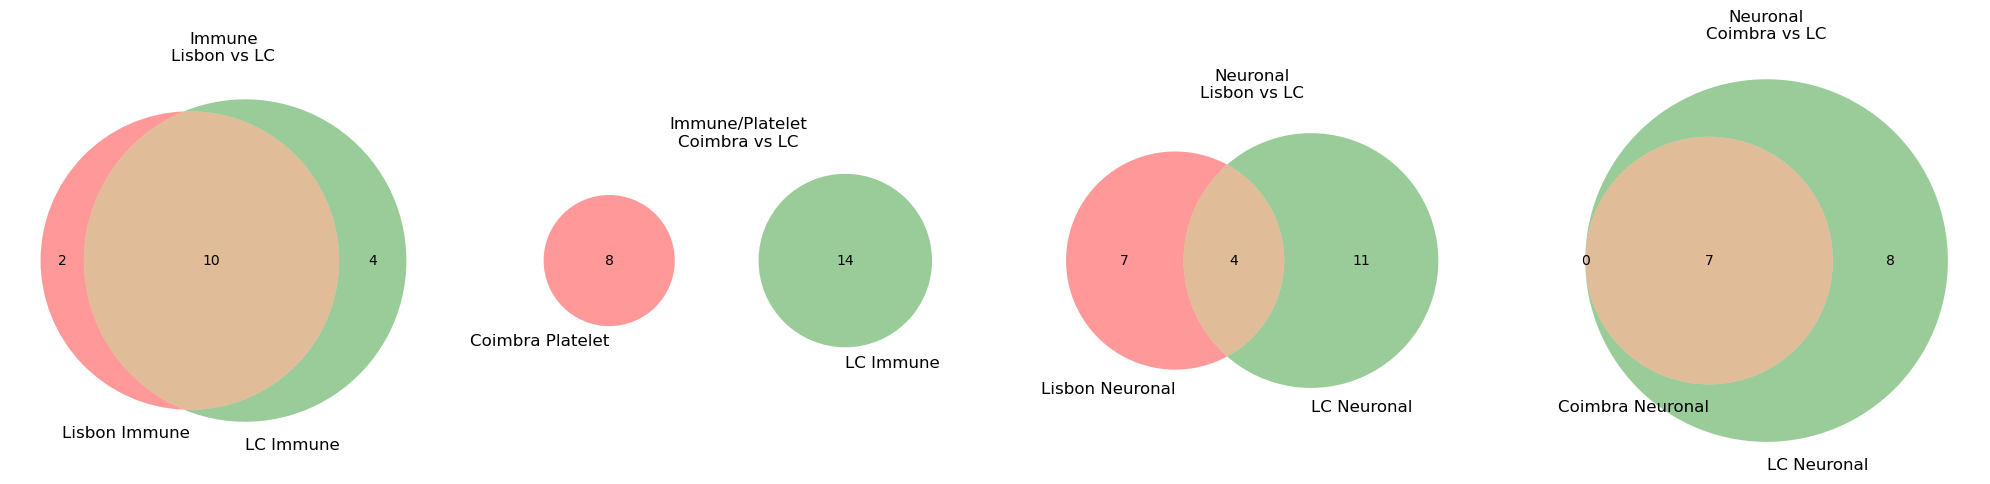

In [79]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5)
)

# =========================================================
# IMMUNE SIGNATURE
# =========================================================

venn2(
    [cluster1_lisbon, cluster1_lc],
    set_labels=("Lisbon Immune", "LC Immune"),
    ax=axes[0]
)
axes[0].set_title("Immune\nLisbon vs LC")

venn2(
    [cluster1_coimbra, cluster1_lc],
    set_labels=("Coimbra Platelet", "LC Immune"),
    ax=axes[1]
)
axes[1].set_title("Immune/Platelet\nCoimbra vs LC")

# =========================================================
# NEURONAL SIGNATURE
# =========================================================

venn2(
    [cluster2_lisbon, cluster2_lc],
    set_labels=("Lisbon Neuronal", "LC Neuronal"),
    ax=axes[2]
)
axes[2].set_title("Neuronal\nLisbon vs LC")

venn2(
    [cluster2_coimbra, cluster2_lc],
    set_labels=("Coimbra Neuronal", "LC Neuronal"),
    ax=axes[3]
)
axes[3].set_title("Neuronal\nCoimbra vs LC")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Cluster_signature_conservation_venn_horizontal.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

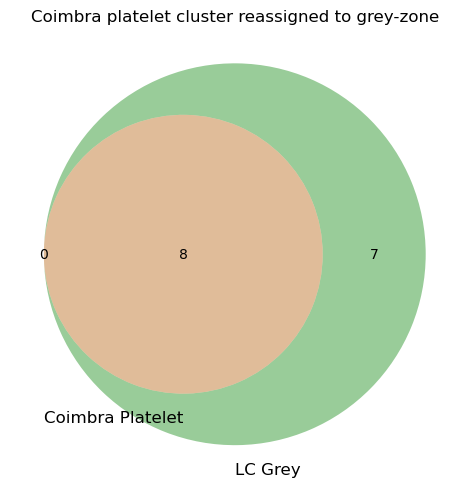

In [88]:
plt.figure(figsize=(5,5))

venn2(
    [coimbra1, grey2_lc],
    set_labels=("Coimbra Platelet", "LC Grey")
)

plt.title("Coimbra platelet cluster reassigned to grey-zone")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Venn_Coimbra_platelet_vs_LC_grey.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
missing_lisbon_immune = (
    cluster1_lisbon - cluster1_lc
)

missing_lisbon_neuronal = (
    cluster2_lisbon - cluster2_lc
)

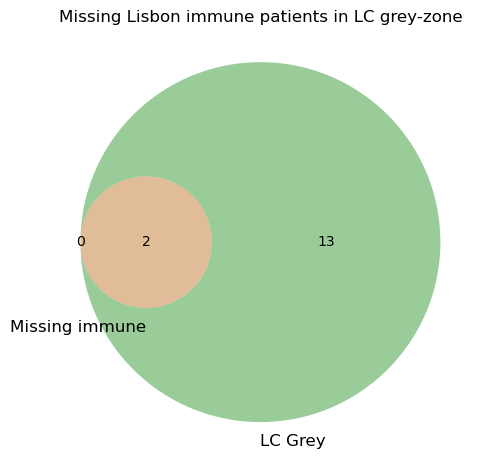

In [89]:
plt.figure(figsize=(5,5))

venn2(
    [missing_lisbon_immune, cluster2_grey_lc],
    set_labels=("Missing immune", "LC Grey")
)

plt.title("Missing Lisbon immune patients in LC grey-zone")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Venn_Missing_immune_vs_LC_grey.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

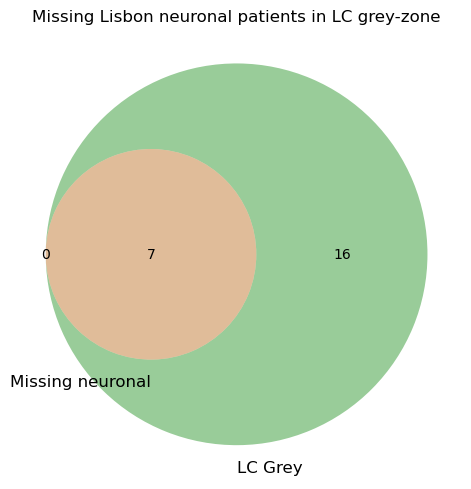

In [90]:
plt.figure(figsize=(5,5))

venn2(
    [missing_lisbon_neuronal, cluster1_grey_lc],
    set_labels=("Missing neuronal", "LC Grey")
)

plt.title("Missing Lisbon neuronal patients in LC grey-zone")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "Venn_Missing_neuronal_vs_LC_grey.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()